In [1]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import torch

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [2]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

In [4]:
from torchvision import datasets, transforms
data_path = '../data-unversioned/p1ch7/'
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

/opt/anaconda3/envs/deep_pytorch/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [5]:
cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [6]:
label_map = {0: 0, 2: 1}
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label])
          for img, label in cifar10 
          if label in [0, 2]]
cifar2_val = [(img, label_map[label])
              for img, label in cifar10_val
              if label in [0, 2]]

In [7]:
import torch.nn as nn

n_out = 2

model = nn.Sequential(
            nn.Linear(
                3072,  # <1>
                512,   # <2>
            ),
            nn.Tanh(),
            nn.Linear(
                512,   # <2>
                n_out, # <3>
            )
        )

In [8]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

In [9]:
x = torch.tensor([1.0, 2.0, 3.0])

softmax(x)

tensor([0.0900, 0.2447, 0.6652])

In [10]:
softmax(x).sum()

tensor(1.)

In [11]:
softmax = nn.Softmax(dim=1)

x = torch.tensor([[1.0, 2.0, 3.0],
                  [3.0, 2.0, 1.0]])

softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.6652, 0.2447, 0.0900]])

In [12]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.Softmax(dim=1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].


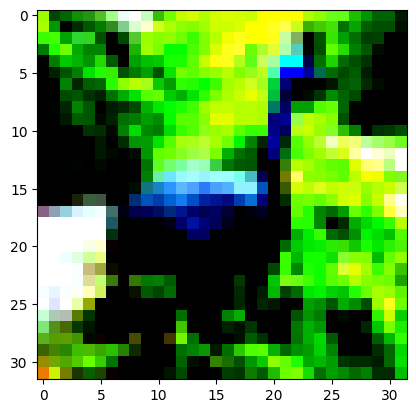

In [13]:
img, _ = cifar2[0]

plt.imshow(img.permute(1, 2, 0))
plt.show()

In [14]:
img_batch = img.view(-1).unsqueeze(0)
img_batch.shape

torch.Size([1, 3072])

In [15]:
out = model(img_batch)
out

tensor([[0.4784, 0.5216]], grad_fn=<SoftmaxBackward0>)

In [16]:
_, index = torch.max(out, dim=1)

index

tensor([1])

In [19]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

In [20]:
loss = nn.NLLLoss()

In [21]:
img, label = cifar2[0]
out = model(img.view(-1).unsqueeze(0))
loss(out, torch.tensor([label]))

tensor(0.7301, grad_fn=<NllLossBackward0>)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 5

for epoch in range(n_epochs):
    for img, label in cifar2:
        img_tensor = img.view(-1).unsqueeze(0)
        label_tensor = torch.tensor([label])
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))
    
    

Epoch: 0, Loss: 7.225336
Epoch: 1, Loss: 6.250650
Epoch: 2, Loss: 3.067836
Epoch: 3, Loss: 7.231179
Epoch: 4, Loss: 6.970220


In [25]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

In [26]:
model = nn.Sequential(
            nn.Linear(3072, 512),
            nn.Tanh(),
            nn.Linear(512, 2),
            nn.LogSoftmax(dim=1))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        img_tensor = imgs.view(batch_size, -1)
        label_tensor = torch.tensor(labels)
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

/var/folders/hb/_y2tps0n0m77ytw9p5xk3kx41dbrb_/T/ipykernel_99386/1182167889.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels)


Epoch: 0, Loss: 0.569934
Epoch: 1, Loss: 0.393809
Epoch: 2, Loss: 0.445801
Epoch: 3, Loss: 0.362268
Epoch: 4, Loss: 0.250847
Epoch: 5, Loss: 0.604102
Epoch: 6, Loss: 0.332456
Epoch: 7, Loss: 0.340713
Epoch: 8, Loss: 0.388191
Epoch: 9, Loss: 0.461160
Epoch: 10, Loss: 0.491739
Epoch: 11, Loss: 0.511085
Epoch: 12, Loss: 0.220694
Epoch: 13, Loss: 0.215982
Epoch: 14, Loss: 0.281591
Epoch: 15, Loss: 0.289936
Epoch: 16, Loss: 0.252250
Epoch: 17, Loss: 0.200544
Epoch: 18, Loss: 0.323398
Epoch: 19, Loss: 0.419916
Epoch: 20, Loss: 0.178024
Epoch: 21, Loss: 0.062671
Epoch: 22, Loss: 0.269617
Epoch: 23, Loss: 0.297262
Epoch: 24, Loss: 0.113849
Epoch: 25, Loss: 0.269317
Epoch: 26, Loss: 0.242853
Epoch: 27, Loss: 0.316751
Epoch: 28, Loss: 0.209804
Epoch: 29, Loss: 0.294648
Epoch: 30, Loss: 0.194611
Epoch: 31, Loss: 0.223175
Epoch: 32, Loss: 0.262868
Epoch: 33, Loss: 0.122255
Epoch: 34, Loss: 0.115496
Epoch: 35, Loss: 0.132326
Epoch: 36, Loss: 0.069975
Epoch: 37, Loss: 0.128164
Epoch: 38, Loss: 0.220

In [27]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.818000


In [28]:
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2),
            nn.LogSoftmax(dim=1))

In [ ]:
model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

loss_fn = nn.CrossEntropyLoss()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)  # Batch size 决定了你对梯度的信任程度。64 或 128 就像是既听取了群众意见，又没被海量信息淹没，是最高效的决策方式。

model = nn.Sequential(
            nn.Linear(3072, 1024),
            nn.Tanh(),
            nn.Linear(1024, 512),
            nn.Tanh(),
            nn.Linear(512, 128),
            nn.Tanh(),
            nn.Linear(128, 2))

learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        batch_size = imgs.shape[0]
        img_tensor = imgs.view(batch_size, -1)
        label_tensor = torch.tensor(labels)
        out = model(img_tensor)
        loss = loss_fn(out, label_tensor)
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

/var/folders/hb/_y2tps0n0m77ytw9p5xk3kx41dbrb_/T/ipykernel_99386/3226406213.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor = torch.tensor(labels)


Epoch: 0, Loss: 0.581924
Epoch: 1, Loss: 0.369544
Epoch: 2, Loss: 0.377022
Epoch: 3, Loss: 0.703112
Epoch: 4, Loss: 0.288263
Epoch: 5, Loss: 0.430992
Epoch: 6, Loss: 0.372167
Epoch: 7, Loss: 0.693180
Epoch: 8, Loss: 0.268134
Epoch: 9, Loss: 0.592190
Epoch: 10, Loss: 0.472669
Epoch: 11, Loss: 0.447027
Epoch: 12, Loss: 0.181739
Epoch: 13, Loss: 0.495403
Epoch: 14, Loss: 0.402021
Epoch: 15, Loss: 0.617421
Epoch: 16, Loss: 0.325070
Epoch: 17, Loss: 0.218567
Epoch: 18, Loss: 0.620144
Epoch: 19, Loss: 0.216263
Epoch: 20, Loss: 0.303409
Epoch: 21, Loss: 0.357599
Epoch: 22, Loss: 0.183989
Epoch: 23, Loss: 0.310309
Epoch: 24, Loss: 0.192062
Epoch: 25, Loss: 0.142323
Epoch: 26, Loss: 0.567564
Epoch: 27, Loss: 0.244036
Epoch: 28, Loss: 0.175024
Epoch: 29, Loss: 0.070562
Epoch: 30, Loss: 0.183159
Epoch: 31, Loss: 0.774479
Epoch: 32, Loss: 0.182109
Epoch: 33, Loss: 0.572698
Epoch: 34, Loss: 0.157940
Epoch: 35, Loss: 0.382405
Epoch: 36, Loss: 0.124072
Epoch: 37, Loss: 0.181117
Epoch: 38, Loss: 0.278

In [31]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 1.000000


In [32]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs.view(imgs.shape[0], -1))
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy: %f" % (correct / total))

Accuracy: 0.819500


In [33]:
numel_list = [p.numel()
              for p in model.parameters()
              if p.requires_grad == True]
sum(numel_list), numel_list

(3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])

In [34]:
first_model = nn.Sequential(
                nn.Linear(3072, 512),
                nn.Tanh(),
                nn.Linear(512, 2),
                nn.LogSoftmax(dim=1))

numel_list = [p.numel() for p in first_model.parameters()]
sum(numel_list), numel_list

(1574402, [1572864, 512, 1024, 2])

In [35]:
linear = nn.Linear(3072, 1024)

linear.weight.shape, linear.bias.shape

(torch.Size([1024, 3072]), torch.Size([1024]))